In [4]:
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else"cpu")
print(device)

cuda


In [15]:
nn.Linear(2,32)

class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,32),
            nn.Tanh(),

            nn.Linear(32,2)
        )
    def forward(self,x):
        return self.network(x)

model = PINN().to(device)
x = torch.linspace(0,1,50)
t = torch.linspace(0,1,50) 

X,T = torch.meshgrid(x,t,indexing="ij")

X_train = torch.cat(
    (
        X.reshape(-1,1),
        T.reshape(-1,1)
    ),

    dim=1
).to(device)

print(X_train.shape)

torch.Size([2500, 2])


In [20]:
X_train.requires_grad_(True)
u_pred = model(X_train)

grads = torch.autograd.grad(
    outputs=u_pred,
    inputs=X_train,
    grad_outputs=torch.ones_like(u_pred),
    create_graph=True
)[0]

u_x = grads[:,0:1]
u_t = grads[:,1:2]

grads2 = torch.autograd.grad(
    outputs=u_x,
    inputs=X_train,
    grad_outputs=torch.ones_like(u_x),
    create_graph=True
)[0]

u_xx = grads2[:,0:1]
residual = u_t - u_x
physical_loss = torch.mean(residual**2)
print(physical_loss)

tensor(0.0144, device='cuda:0', grad_fn=<MeanBackward0>)


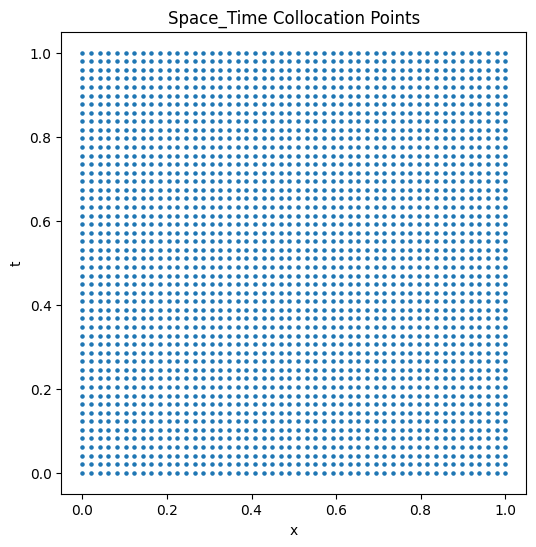

In [21]:
plt.figure(figsize=[6,6])
plt.scatter(X_train[:,0].cpu().detach(),
            X_train[:,1].cpu().detach(),
            s=5)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Space_Time Collocation Points")
plt.show()
           

In [23]:
print(u_pred.shape)
print(u_pred[:10])

torch.Size([2500, 2])
tensor([[-0.1000, -0.1943],
        [-0.1008, -0.1950],
        [-0.1017, -0.1958],
        [-0.1026, -0.1965],
        [-0.1034, -0.1973],
        [-0.1043, -0.1981],
        [-0.1051, -0.1989],
        [-0.1060, -0.1997],
        [-0.1068, -0.2006],
        [-0.1077, -0.2014]], device='cuda:0', grad_fn=<SliceBackward0>)


In [24]:
print(u_x.shape)
print(u_t.shape)

torch.Size([2500, 1])
torch.Size([2500, 1])


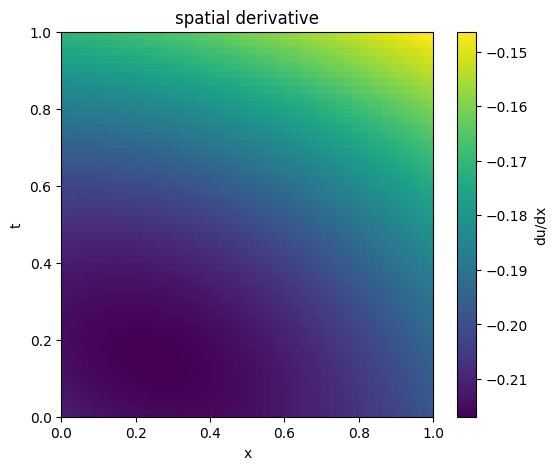

In [27]:
ux_plot = u_x.detach().cpu().numpy().reshape(50,50)

plt.figure(figsize=(6,5))
plt.imshow(
    ux_plot,
    extent=[0,1,0,1],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="du/dx")
plt.xlabel("x")
plt.ylabel("t")
plt.title("spatial derivative")
plt.show()

Epoch 0: Loss = 0.014374
Epoch 100: Loss = 0.000005
Epoch 200: Loss = 0.000004
Epoch 300: Loss = 0.000002
Epoch 400: Loss = 0.000001
Epoch 500: Loss = 0.000001
Epoch 600: Loss = 0.000001
Epoch 700: Loss = 0.000000
Epoch 800: Loss = 0.000000
Epoch 900: Loss = 0.000000


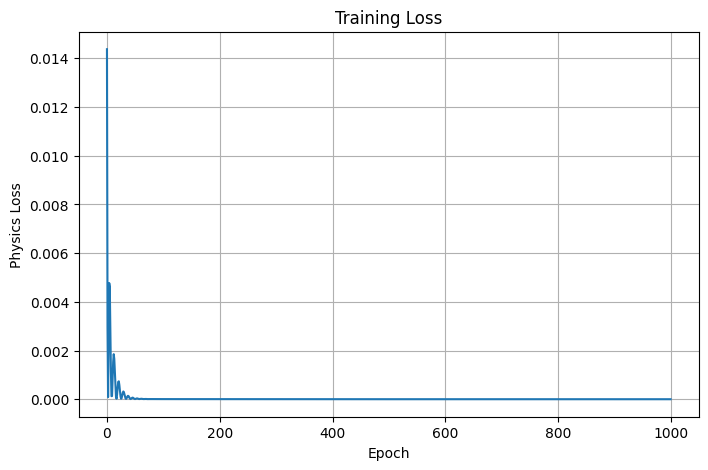

In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_history=[]
epochs = 1000

for epoch in range(epochs):

    optimizer.zero_grad()

    # Forward pass
    u_pred = model(X_train)

    # First derivatives
    grads = torch.autograd.grad(
        outputs=u_pred,
        inputs=X_train,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    # PDE residual
    residual = u_t - u_x

    # Physics loss
    physics_loss = torch.mean(residual**2)

    # Backpropagation
    physics_loss.backward()

    optimizer.step()

    # Save loss
    loss_history.append(physics_loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Loss = {physics_loss.item():.6f}")

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Physics Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()